In [1]:
import numpy as np
import glob
import lgdo.lh5 as lh5
import os, json
import copy
from pathlib import Path
import shutil
import glob
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
import pandas as pd
from tqdm.notebook import tqdm
import awkward as ak
import polars as pl

from helper_lib import *
from resolution_extraction import weighted_resolution_from_nested_dict as wres_full
from resolution_extraction import weighted_resolution_per_detector as wres_det
from resolution_extraction import weighted_value_per_det_type as wval_dtype
from resolution_extraction import weighted_resolution_per_detector_type as wres_dtype
from resolution_extraction import get_eres_per_detector
import resolution_extraction as rex

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)
chmap_ak = ak.Array(chmap.group("system").geds.values())

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")
DET_TYPE_MAP = {"B": "BEGe", "C": "COAX", "V": "ICPC", "P": "PPC"}

simulated_energies = list(range(200, 1100, 100))

outdir_name = "./v1/parquet/"
dictionaries_dir = "./v1/dictionaries"

eres_dict = Props.read_from(f"{dictionaries_dir}/eres_dict.yaml")
rawid_by_det_type = Props.read_from(f'{dictionaries_dir}/rawid_by_det_type.yaml')

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f0d0e68db70>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f0d0e68e110>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f0d0e68e9d0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f0d0e68f150>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f0d0e6addf0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f0d0e6aff10>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

In [3]:
pet_file = config['tier_pet']+'/phy/*.lh5'

pet_files = glob.glob(pet_file)

In [4]:
data = lh5.read_as(
    "evt", 
    pet_files, 
    field_mask=["coincident", "geds", "trigger"],
    library="ak",
)

## Custom function

In [21]:
from cutting_lib import prepare_pet_dataset, filter_dataset, apply_quality_cuts, compute_group_exposure


In [22]:
pet_file = config['tier_pet']+'/phy/*.lh5'
pet_files = glob.glob(pet_file)

In [13]:
ICPC = [name for name in chmap.group('type')['icpc'].map('name')]
BEGe = [name for name in chmap.group('type')['bege'].map('name')]
COAX = [name for name in chmap.group('type')['coax'].map('name')]
PPC  = [name for name in chmap.group('type')['ppc'].map('name')]

### group division

In [14]:
ICPC_group1 = [
    'V05612B',
    'V09724A',
    'V05267A',
    'V05612A',
    'V08682B',
    'V05268B',
    'V08682A',
    'V09372A',
    'V09374A',
    'V04545A'
]

ICPC_group1_dict = {det:'all' for det in ICPC_group1}

ICPC_group1_dict['V08682B'] = {
    'p06': 'all',
    'p07': 'all',
    'p08': 'all',
    'p09': 'all',
}

ICPC_group1_dict['V01389A'] = {
    'p09': 'all',
}

ICPC_group1_dict

{'V05612B': 'all',
 'V09724A': 'all',
 'V05267A': 'all',
 'V05612A': 'all',
 'V08682B': {'p06': 'all', 'p07': 'all', 'p08': 'all', 'p09': 'all'},
 'V05268B': 'all',
 'V08682A': 'all',
 'V09372A': 'all',
 'V09374A': 'all',
 'V04545A': 'all',
 'V01389A': {'p09': 'all'}}

In [15]:
ICPC_group2_dict = {det:'all' for det in ICPC if det not in ICPC_group1}

ICPC_group2_dict['V01389A'] = 'all'
ICPC_group2_dict['V08682B'] = 'all'


for det in ICPC_group1_dict:

    if det in ICPC_group2_dict:
        ICPC_group2_dict[det] = {}

        for p in ICPC_group1_dict[det]:
            ICPC_group2_dict[det][f'~{p}'] = ICPC_group1_dict[det][p]

ICPC_group2_dict

{'V02160A': 'all',
 'V02160B': 'all',
 'V05261B': 'all',
 'V05266A': 'all',
 'V05266B': 'all',
 'V07647A': 'all',
 'V07647B': 'all',
 'V00074A': 'all',
 'V04549A': 'all',
 'V07298B': 'all',
 'V01386A': 'all',
 'V01403A': 'all',
 'V01404A': 'all',
 'V01406A': 'all',
 'V01415A': 'all',
 'V02162B': 'all',
 'V02166B': 'all',
 'V04199A': 'all',
 'V05267B': 'all',
 'V07646A': 'all',
 'V07302B': 'all',
 'V00048B': 'all',
 'V00050A': 'all',
 'V00050B': 'all',
 'V01387A': 'all',
 'V05261A': 'all',
 'V05268A': 'all',
 'V07302A': 'all',
 'V00048A': 'all',
 'V01240A': 'all',
 'V01389A': {'~p09': 'all'},
 'V08682B': {'~p06': 'all', '~p07': 'all', '~p08': 'all', '~p09': 'all'}}

In [16]:
BEGe_group_dict = {det:'all' for det in BEGe}

In [17]:
PPC_group_dict = {det:'all' for det in PPC}

COAX_group_dict = {det:'all' for det in COAX}

### Retrieve data

In [9]:
df_all = prepare_pet_dataset(
    pet_files,
    chmap=chmap,  
)

df_all = df_all.filter(~pl.col("coincident_spms"))

In [24]:
df_finale  = filter_dataset(df_all, ICPC_group1_dict)
df_finale2 = filter_dataset(df_all, ICPC_group2_dict)
df_BEGe    = filter_dataset(df_all, BEGe_group_dict)
df_COAX    = filter_dataset(df_all, COAX_group_dict)
df_PPC    = filter_dataset(df_all, PPC_group_dict)

energia = df_finale["energy"].to_numpy()
energia2 = df_finale2["energy"].to_numpy()
energia_PPC = df_PPC["energy"].to_numpy()
energia_COAX = df_COAX["energy"].to_numpy()
energia_BEGe = df_BEGe["energy"].to_numpy()

expo_group1 = compute_group_exposure(eres_dict, ICPC_group1_dict)
expo_group2 = compute_group_exposure(eres_dict, ICPC_group2_dict)
expo_BEGe   = compute_group_exposure(eres_dict, BEGe_group_dict)
expo_PPC    = compute_group_exposure(eres_dict, PPC_group_dict)
expo_COAX   = compute_group_exposure(eres_dict, COAX_group_dict)


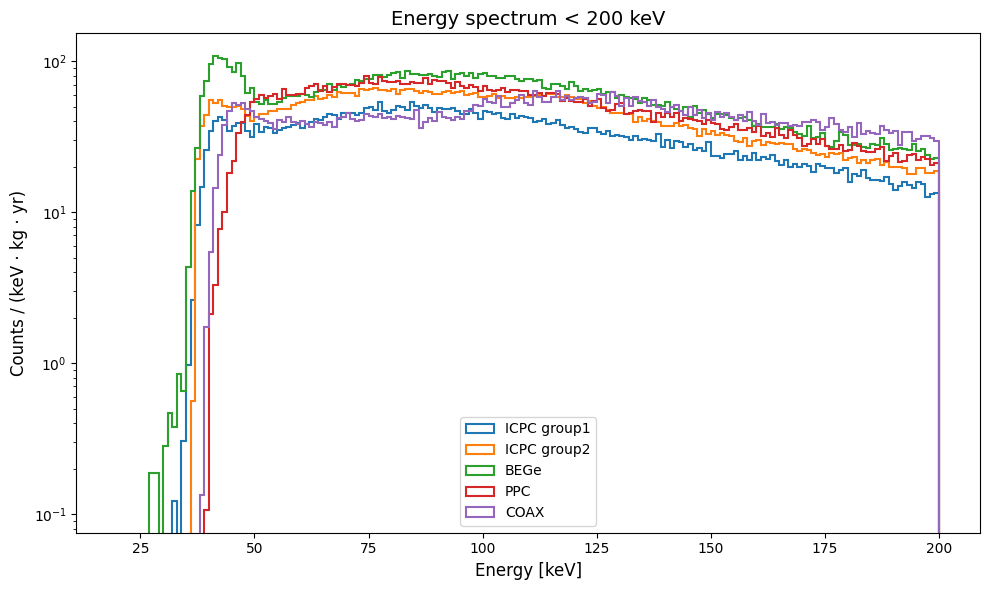

In [28]:
emin = 20
emax = 200

bins = emax-emin

plt.figure(figsize=(10, 6))


plt.hist(energia, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5,
         weights=np.ones_like(energia) / expo_group1, label="ICPC group1")

plt.hist(energia2, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5,
         weights=np.ones_like(energia2) / expo_group2, label="ICPC group2")

plt.hist(energia_BEGe, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, 
         weights=np.ones_like(energia_BEGe) / expo_BEGe, label="BEGe")

plt.hist(energia_PPC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, 
         weights=np.ones_like(energia_PPC) / expo_PPC, label="PPC")
plt.hist(energia_COAX, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, 
         weights=np.ones_like(energia_COAX) / expo_COAX, label="COAX")

# plt.axvline(1024, ls='--')

plt.xlabel("Energy [keV]", fontsize=12)
plt.ylabel("Counts / (keV · kg · yr)", fontsize=12)
plt.title(f"Energy spectrum < {emax} keV", fontsize=14)
plt.yscale("log")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(f"./plots/bkg-stectra_{emax}.png", dpi=300)

plt.show()

# print("Plot salvato come 'energy_spectrum.png'")
